# 📦 Environment dependencies

To ensure all clustering algorithms and astronomical datasets are available.

> **Note:** Run this in your terminal or use `!` before the command if running directly in a Jupyter cell.

```bash
pip install numpy seaborn matplotlib scikit-fuzzy astroML plotly nbformat

In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import skfuzzy as fuzz
from astroML.datasets import fetch_sdss_specgals as specgals
from scipy.stats import entropy
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# --<ignore>--
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")

---
### **🌌 SDSS Spectroscopic Galaxies** <br>
**Resources:** [Astronomical Spectroscopy (Wiki)](https://en.wikipedia.org/wiki/Astronomical_spectroscopy) | [Official astroML Docs](https://www.astroml.org/)

This dataset contains **661,598 objects** filtered for high scientific fidelity:
* **Redshift ($z$):** Restricted to $0.02 < z < 0.2$ to ensure spectral line reliability.
* **Magnitudes:** Photometric cuts (e.g., $10 < r < 18$) remove saturated or excessively faint objects.
* **Spectral Quality:** Limited to objects with low statistical error (`rChi2 < 2`) and precise redshifts.

---

#### **Key Spectral Characteristics**
Beyond coordinates (RA, Dec), the set includes specialized **Pipeline Parameters**:

1. **Emission Lines:** Fluxes for Hydrogen ($H\alpha, H\beta, H\delta$) and Oxygen ($OIII$), critical for **BPT diagrams**.

2. **Evolution Indicators:** The **D4000** parameter (4000 Å break) defines the age of stellar populations.
3. **Physical Quantities:**
    * `sfr_tot_p50`: Total Star Formation Rate.
    * `lgm_tot_p50`: Total Stellar Mass ($log_{10}$ solar masses).
    * `bptclass`: Spectral type (e.g., Star-forming, AGN, or Composite).

---

<div style="display: flex; flex-direction: row; gap: 10px; align-items: flex-start; justify-content: center; width: 100%;">

  <figure style="margin: 0; text-align: center; width: 48%;">
    <img src="Star%20Spectroscopy.png" style="width: 100%; height: auto; border: 2px solid #1C3D5A; border-radius: 5px; box-shadow: 0px 4px 15px rgba(0,0,0,0.5);" alt="Spectroscopy Analysis">
    <figcaption style="font-size: 16px; color: #D3D3D3; margin-top: 12px; font-weight: bold;">Figure A: Webb Spectroscopic Analysis</figcaption>
  </figure>

  <figure style="margin: 0; text-align: center; width: 48%;">
    <img src="Composition.png" style="width: 100%; height: auto; border: 2px solid #1C3D5A; border-radius: 5px; box-shadow: 0px 4px 15px rgba(0,0,0,0.5);" alt="Data Composition Breakdown">
    <figcaption style="font-size: 16px; color: #D3D3D3; margin-top: 12px; font-weight: bold;">Figure B: Data Features & Structure</figcaption>
  </figure>

</div>

---



### 🎨 1. Photometric Colors (`u-g`, `g-r`, `r-i`)
In astronomy, a **"color"** is the difference between the magnitudes of two different filters. 
* **Calculation:** `color = Magnitude_A - Magnitude_B`
* **Significance:** Colors act as a proxy for a galaxy's **temperature** and **stellar age**. 
    * **`u-g`**: Highly sensitive to recent star formation. High values indicate "Red and Dead" elliptical galaxies, while low values indicate "Young and Blue" star-forming galaxies.
    * **`g-r`**: Used to identify the "Red Sequence" and "Blue Cloud" populations in Color-Magnitude diagrams.



### 🚀 2. Redshift (`Redshift` / `z`)
* **Source:** `data['z']`
* **Significance:** Redshift measures how much the light from a galaxy has been stretched by the expansion of the universe. 
    * It serves as a coordinate for **distance** (Hubble's Law).
    * It allows the algorithm to account for "look-back time," as galaxies further away appear as they were billions of years ago.

### ⚖️ 3. Stellar Mass (`Mass (log)`)
* **Source:** `data['lgm_tot_p50']`
* **Significance:** This represents the median estimate ($p50$) of the total mass of all stars in the galaxy, expressed as $log_{10}(M_{Solar})$.
    * High-mass galaxies tend to be elliptical and "quenched" (no longer forming stars).
    * Low-mass galaxies are typically spiral or irregular.

### 🧪 4. Spectral Classification (`Type`)
* **Source:** `data['bptclass']` (BPT Diagram Classification)
* **Significance:** This is our "Ground Truth" label. It categorizes galaxies based on their emission line ratios:
    1. **Star-Forming**: Galaxies actively creating new stars.
    2. **Composite**: Mixed activity.
    3. **AGN**: Galaxies with an "Active Galactic Nucleus" (powered by a supermassive black hole).
    4. **LINER**: Low-ionization nuclear emission-line regions.

In [2]:
class GalaxyFuzzyEngine3D:
    def __init__(self, sample_size=5000, fuzzifier=1.65):
        self.sample_size = sample_size
        self.m = fuzzifier 
        self.features = None
        self.u = None
        self.fpc = None
        
        self.sample_size = sample_size
        self.colors = ['#00E5FF', '#FFD700', '#E03C31', '#A6E22E', '#FF2E88']
        sns.set_style("darkgrid", {"axes.facecolor": "#0B192E"})



    def Load_3D(self):
        data_raw = specgals()
        u_g = data_raw['modelMag_u'] - data_raw['modelMag_g']
        g_r = data_raw['modelMag_g'] - data_raw['modelMag_r']
        z = data_raw['z'] 
        
        mask = (u_g > 0.5) & (u_g < 3.0) & (g_r > 0.2) & (g_r < 1.8) & (z < 0.4)
        X = np.vstack([u_g[mask], g_r[mask], z[mask]]).T
        self.features = X[:self.sample_size]
        return self


    def fit(self, n_clusters=3):
        cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
            self.features.T, c=n_clusters, m=self.m, 
            error=0.005, maxiter=1000
        )
        self.u = u
        self.fpc = fpc
        return self


    def Interactive_Mode(self):
        hard_labels = np.argmax(self.u, axis=0)
        pt_entropy = entropy(self.u)
        
        hover_text = [f"Spiral: {m[0]:.2f}<br>Elliptical: {m[1]:.2f}<br>Transition: {m[2]:.2f}" 
                      for m in self.u.T]

        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{'type': 'scene'}, {'type': 'scene'}]],
            subplot_titles=(f'3D Morphologies (FPC: {self.fpc:.3f})', 
                            'Transition Entropy (Uncertainty)')
        )

        fig.add_trace(
            go.Scatter3d(
                x=self.features[:, 0], y=self.features[:, 1], z=self.features[:, 2],
                mode='markers', text=hover_text, hoverinfo='text',
                marker=dict(size=2.5, color=hard_labels, colorscale='Portland', opacity=0.7),
            ), row=1, col=1
        )

        fig.add_trace(
            go.Scatter3d(
                x=self.features[:, 0], y=self.features[:, 1], z=self.features[:, 2],
                mode='markers', text=hover_text, hoverinfo='text',
                marker=dict(size=2.5, color=pt_entropy, colorscale='Hot', opacity=0.8,
                            colorbar=dict(title="Entropy", x=1.02)),
            ), row=1, col=2
        )

        fig.update_layout(
            template="plotly_dark",
            title="<b>Galaxy Fuzzy Explorer 3D</b>: The Morphological Continuum",
            scene=dict(xaxis_title='u-g', yaxis_title='g-r', zaxis_title='Redshift'),
            scene2=dict(xaxis_title='u-g', yaxis_title='g-r', zaxis_title='Redshift'),
            updatemenus=[dict(type='buttons', showactive=False,
                              buttons=[dict(label='Play Rotation',
                                            method='animate',
                                            args=[None, dict(frame=dict(duration=50, redraw=True), 
                                                              fromcurrent=True)])])],
            showlegend=False
        )

        fig.frames = [go.Frame(layout=dict(scene_camera=dict(eye=dict(x=1.5*np.cos(theta), 
                                                                      y=1.5*np.sin(theta), 
                                                                      z=0.5))))
                      for theta in np.linspace(0, 2*np.pi, 100)]
        fig.show()
        
        
    
    def Explore_Dataset(self):
        data = specgals()

        df = pd.DataFrame()
        df['u-g'] = data['modelMag_u'] - data['modelMag_g']
        df['g-r'] = data['modelMag_g'] - data['modelMag_r']
        df['r-i'] = data['modelMag_r'] - data['modelMag_i']
        df['Redshift'] = data['z']
        df['Mass (log)'] = data['lgm_tot_p50']
        df['Type'] = data['bptclass']

        df_sample = df.sample(min(1500, len(df)))

        plot_colors = getattr(self, 'colors', ['#00E5FF', '#FFD700', '#E03C31'])

        g = sns.pairplot(df_sample, hue='Type', palette=plot_colors[:5], 
                         corner=True, diag_kind="kde",
                         plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'none'})

        g.fig.set_facecolor('#0B192E')
        for ax in g.axes.flatten():
            if ax is not None:
                ax.set_facecolor('#0B192E')
                ax.tick_params(colors='white', labelsize=9)
                ax.xaxis.label.set_color('white')
                ax.yaxis.label.set_color('white')
                ax.grid(color='#1C3D5A', alpha=0.3)

        g.fig.suptitle("SDSS GALAXY: FEATURE CORRELATIONS", 
                       color="#E0D69C", fontsize=16, fontweight='bold', y=1.02)
        
        if g._legend:
            plt.setp(g._legend.get_texts(), color='white')
            plt.setp(g._legend.get_title(), color='white')

        plt.show()

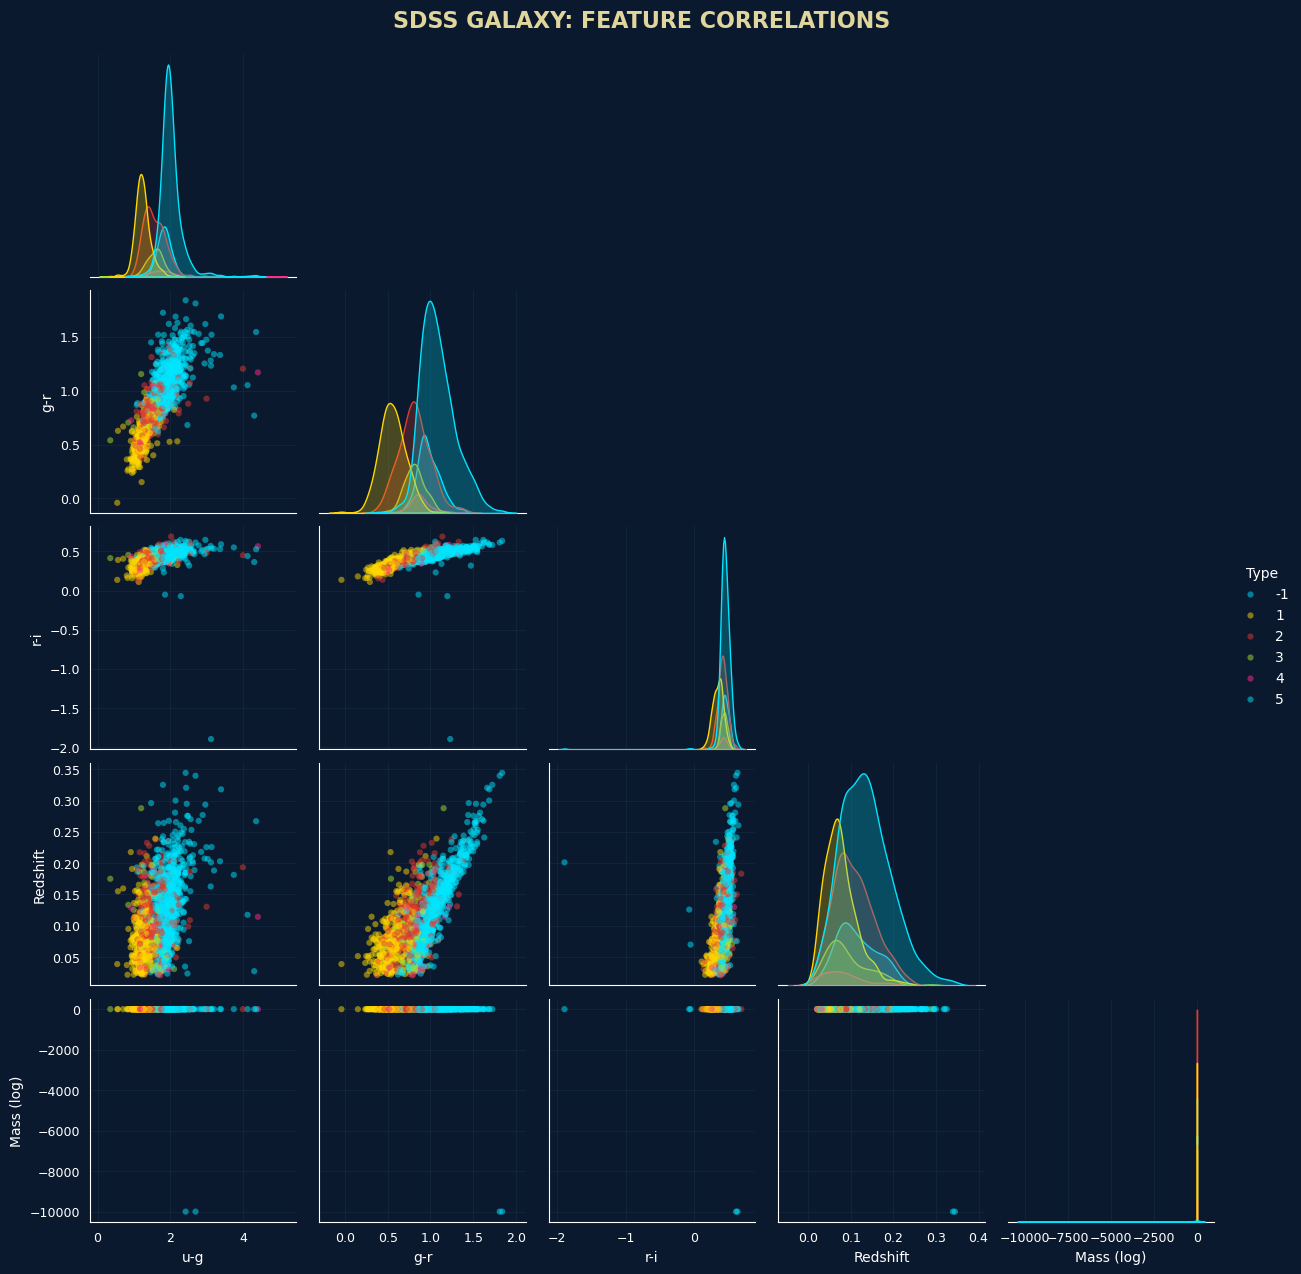

In [10]:
engine = GalaxyFuzzyEngine3D(sample_size=5000)
engine.Explore_Dataset()

In [4]:
engine.Load_3D().fit(n_clusters=3).Interactive_Mode()